In [8]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import json
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DATA_DIR   = Path('../../data/spambase_10_40_50')
SCORES_DIR = Path('../../outputs/noise_scoring/20260324_203954')
ADV_DIR    = Path('../../outputs/targeted_vaccination_10_40_50')
OUTPUT_DIR = Path('../../outputs/perturbation_subspace_decomposition')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LAMBDAS = {'aggressive': 0.1, 'stealthy': 50.0}
K_RANKS = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]
TIER_PCT = 20
EPS_NORM = 1e-10

print(f'Tier percentile: top/bottom {TIER_PCT}%')
print(f'k_ranks: {K_RANKS}')
print(f'Outputs at: {OUTPUT_DIR}')

Device: cuda
GPU: NVIDIA RTX A6000
Tier percentile: top/bottom 20%
k_ranks: [1, 2, 3, 5, 10, 15, 20, 30, 40, 50, 57]
Outputs at: ../../outputs/perturbation_subspace_decomposition


## 1. Load Data, Model, Scores, Basis, Adversarial Samples

In [9]:
data = np.load(DATA_DIR / 'train_test_data.npz')
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test']
n_test, n_features = X_test.shape


class SpambaseNet(nn.Module):
    def __init__(self, D_in):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.layer(x).squeeze(0)
        return self.layer(x)


checkpoint = torch.load(DATA_DIR / 'spambase_mlp.pth', map_location=device)
model = SpambaseNet(checkpoint['D_in']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

with torch.no_grad():
    test_preds = model(torch.FloatTensor(X_test).to(device)).argmax(dim=1).cpu().numpy()
correct_mask = (test_preds == y_test)
correct_indices = np.where(correct_mask)[0]
n_correct = len(correct_indices)

svd_basis = np.load(DATA_DIR / 'clean_svd_basis.npz')
Vt = svd_basis['Vt_svd'].astype(np.float32)
S  = svd_basis['S_svd']
assert Vt.shape == (n_features, n_features), f'Vt shape {Vt.shape} != ({n_features},{n_features})'

score1_removal_order = np.load(SCORES_DIR / 'test_clean_data_score1_removed_index.npy').astype(int)
score2_value         = np.load(SCORES_DIR / 'test_clean_data_score2_noise_scores.npy')

adv_data = np.load(ADV_DIR / 'adversarial_samples.npz')
X_adv = {
    'aggressive': adv_data['X_adv_aggressive'].astype(np.float32),
    'stealthy':   adv_data['X_adv_stealthy'].astype(np.float32),
}
attack_success = {
    'aggressive': adv_data['success_aggressive'].astype(bool),
    'stealthy':   adv_data['success_stealthy'].astype(bool),
}

print(f'Test set: {n_test} × {n_features}')
print(f'Correctly classified: {n_correct}/{n_test} ({n_correct/n_test:.2%})')
print(f'Vt: {Vt.shape}, top-10 singular values: {S[:10].round(2)}')
for regime in LAMBDAS:
    n_succ = int(attack_success[regime][correct_indices].sum())
    print(f'  {regime:>10s}: {n_succ}/{n_correct} successful attacks ({n_succ/n_correct:.2%})')

Test set: 2301 × 57
Correctly classified: 2058/2301 (89.44%)
Vt: (57, 57), top-10 singular values: [4.76 3.28 2.39 2.28 2.13 2.06 2.05 1.96 1.89 1.7 ]
  aggressive: 2058/2058 successful attacks (100.00%)
    stealthy: 1519/2058 successful attacks (73.81%)


## 2. Score Orderings and Tier Definitions


In [10]:
score1_order = np.array([idx for idx in score1_removal_order if correct_mask[idx]])
score2_order = np.array([idx for idx in np.argsort(score2_value)[::-1] if correct_mask[idx]])

n_eligible = len(score1_order)
n_tier = max(1, int(n_eligible * TIER_PCT / 100))

tier_indices = {}
for score_name, order in [('Score 1', score1_order), ('Score 2', score2_order)]:
    tier_indices[score_name] = {
        'noisy':      set(order[:n_tier].tolist()),
        'structural': set(order[-n_tier:].tolist()),
    }

for score_name in tier_indices:
    n_n = len(tier_indices[score_name]['noisy'])
    n_s = len(tier_indices[score_name]['structural'])
    print(f'{score_name}: noisy={n_n}, structural={n_s} (top/bottom {TIER_PCT}% of {n_eligible})')

Score 1: noisy=411, structural=411 (top/bottom 20% of 2057)
Score 2: noisy=411, structural=411 (top/bottom 20% of 2057)


## 3. Compute Perturbations and Projections


In [11]:
per_sample = {regime: {} for regime in LAMBDAS}

for regime in LAMBDAS:
    R = X_adv[regime] - X_test                          # (n_test, n_features)
    norms_sq = np.einsum('ij,ij->i', R, R)              # (n_test,)
    success = attack_success[regime] & correct_mask     # successful AND correctly classified
    success &= (norms_sq > EPS_NORM ** 2)               # guard against ~0 perturbations

    R_succ = R[success]                                 # (n_succ, n_features)
    norms_sq_succ = norms_sq[success]                   # (n_succ,)
    proj = R_succ @ Vt.T                                # (n_succ, n_features); column j = v_j^T r_i
    proj_sq = proj ** 2
    cum_head_energy = np.cumsum(proj_sq, axis=1)        # (n_succ, n_features); cum at k = top-k energy
    alpha = cum_head_energy / norms_sq_succ[:, None]    # (n_succ, n_features); alpha[i, k-1] = alpha_i(k)
    per_dir_energy = proj_sq / norms_sq_succ[:, None]   # (n_succ, n_features)

    per_sample[regime] = {
        'indices': np.where(success)[0],
        'norms_sq': norms_sq_succ,
        'alpha': alpha.astype(np.float32),
        'per_dir_energy': per_dir_energy.astype(np.float32),
    }

for regime, d in per_sample.items():
    print(f'{regime}: {len(d["indices"])} successful perturbations analyzed; '
          f'mean ||r||^2 = {d["norms_sq"].mean():.4f}')

aggressive: 2058 successful perturbations analyzed; mean ||r||^2 = 1.8879
stealthy: 1519 successful perturbations analyzed; mean ||r||^2 = 1.2511


## 4. Mean Cumulative Energy by Tier

Hypothesis: the **structural** curve sits *above* the **noisy** curve at small $k$ (more head energy). Convergence to 1 at $k = n_{features}$ is by construction.

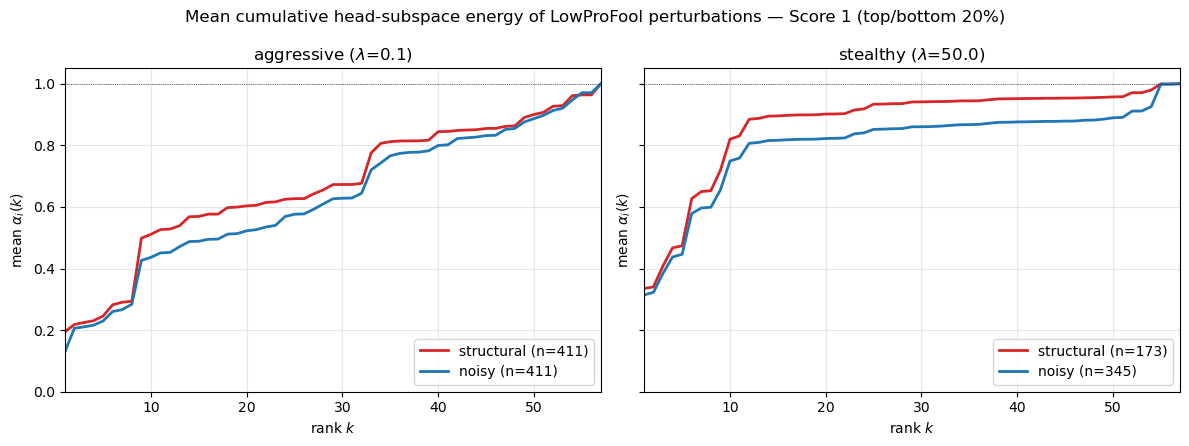

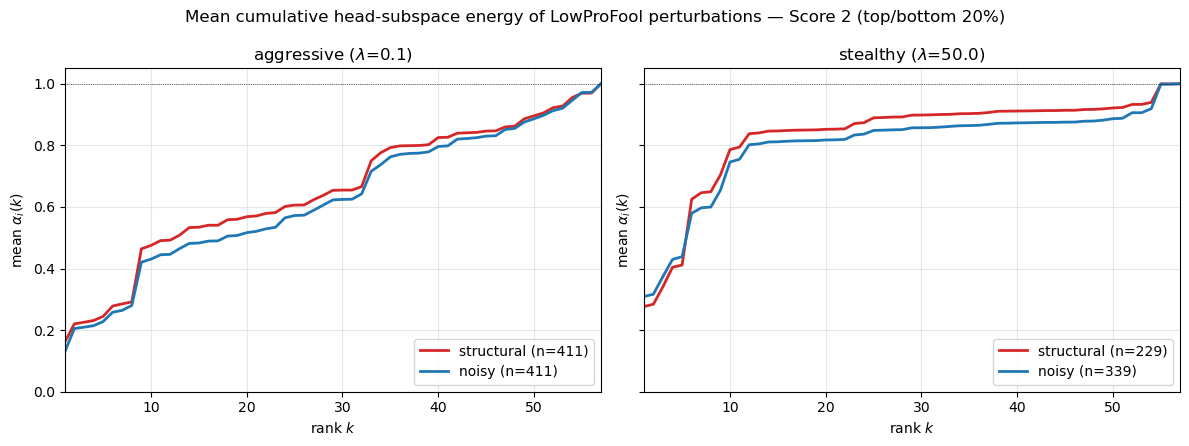


Head of curve_df:
score_type     regime       tier  k  mean_alpha    std_alpha  n_samples
   Score 1 aggressive structural  1    0.194277 4.511022e-02        411
   Score 1 aggressive structural  2    0.218260 1.841447e-02        411
   Score 1 aggressive structural  3    0.224494 1.720430e-02        411
   Score 1 aggressive structural  5    0.245792 1.566469e-02        411
   Score 1 aggressive structural 10    0.511127 3.999423e-02        411
   Score 1 aggressive structural 15    0.569185 3.739417e-02        411
   Score 1 aggressive structural 20    0.603544 3.585684e-02        411
   Score 1 aggressive structural 30    0.672868 1.658194e-02        411
   Score 1 aggressive structural 40    0.844525 1.925395e-02        411
   Score 1 aggressive structural 50    0.900005 5.321698e-03        411
   Score 1 aggressive structural 57    1.000000 1.531666e-07        411
   Score 1 aggressive      noisy  1    0.128891 8.207779e-02        411


In [12]:
TIER_COLORS = {'structural': '#d62728', 'noisy': '#1f77b4'}
curve_records = []
ks_full = np.arange(1, n_features + 1)

for score_name in tier_indices:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for ax, regime in zip(axes, LAMBDAS):
        idx_succ = per_sample[regime]['indices']
        alpha = per_sample[regime]['alpha']
        for tier_name in ['structural', 'noisy']:
            tier_set = tier_indices[score_name][tier_name]
            mask = np.array([idx in tier_set for idx in idx_succ])
            n_in_tier = int(mask.sum())
            if n_in_tier == 0:
                continue
            mean_curve = alpha[mask].mean(axis=0)
            std_curve  = alpha[mask].std(axis=0)
            ax.plot(ks_full, mean_curve, color=TIER_COLORS[tier_name], lw=2,
                    label=f'{tier_name} (n={n_in_tier})')
            for k in K_RANKS:
                curve_records.append({
                    'score_type': score_name, 'regime': regime, 'tier': tier_name,
                    'k': k, 'mean_alpha': float(mean_curve[k - 1]),
                    'std_alpha': float(std_curve[k - 1]), 'n_samples': n_in_tier,
                })
        ax.set_xlabel('rank $k$')
        ax.set_ylabel(r'mean $\alpha_i(k)$')
        ax.set_title(f'{regime} ($\\lambda$={LAMBDAS[regime]})')
        ax.set_xlim(1, n_features); ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.3); ax.legend(loc='lower right')
        ax.axhline(1.0, color='k', lw=0.5, ls=':')
    fig.suptitle(f'Mean cumulative head-subspace energy of LowProFool perturbations — {score_name} '
                 f'(top/bottom {TIER_PCT}%)')
    fig.tight_layout()
    fname = f'mean_cumulative_energy_{score_name.lower().replace(" ", "")}.png'
    fig.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()

curve_df = pd.DataFrame(curve_records)
print('\nHead of curve_df:')
print(curve_df.head(12).to_string(index=False))

## 5. Per-Direction Energy Spectrum


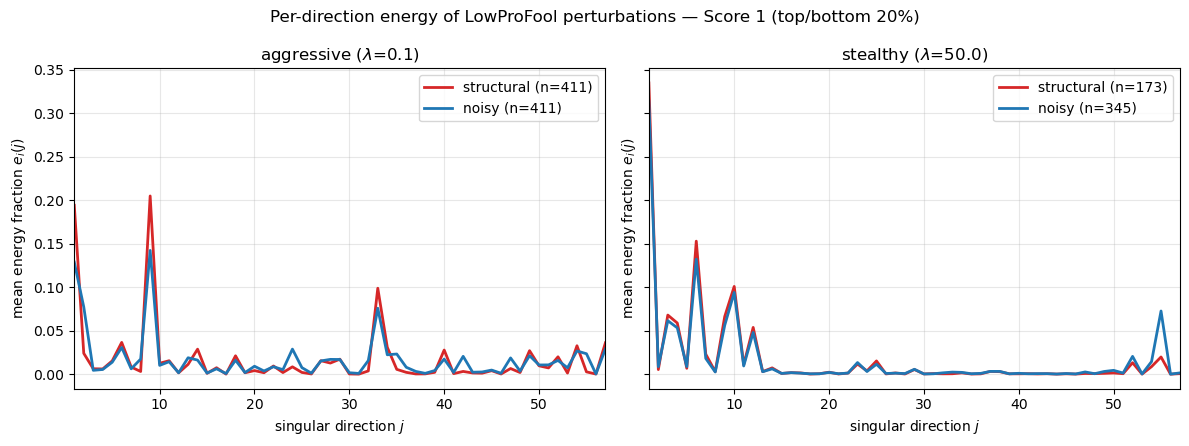

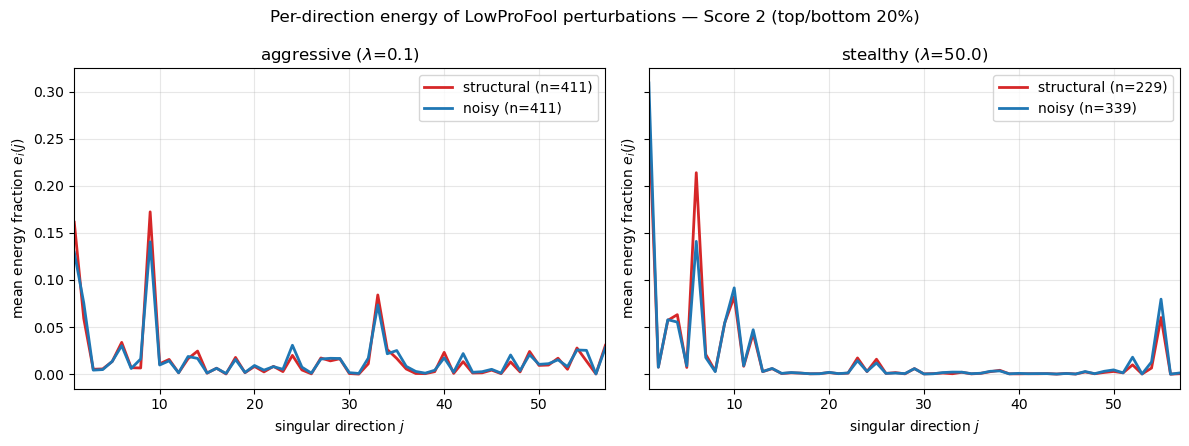


Head of direction_df:
score_type     regime       tier  singular_index  mean_energy_fraction  n_samples
   Score 1 aggressive structural               1              0.194277        411
   Score 1 aggressive structural               2              0.023983        411
   Score 1 aggressive structural               3              0.006234        411
   Score 1 aggressive structural               4              0.006004        411
   Score 1 aggressive structural               5              0.015293        411
   Score 1 aggressive structural               6              0.036537        411
   Score 1 aggressive structural               7              0.008207        411
   Score 1 aggressive structural               8              0.003081        411
   Score 1 aggressive structural               9              0.204967        411
   Score 1 aggressive structural              10              0.012544        411
   Score 1 aggressive structural              11              0.015447     

In [13]:
direction_records = []
ks_full = np.arange(1, n_features + 1)

for score_name in tier_indices:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for ax, regime in zip(axes, LAMBDAS):
        idx_succ = per_sample[regime]['indices']
        e = per_sample[regime]['per_dir_energy']
        for tier_name in ['structural', 'noisy']:
            tier_set = tier_indices[score_name][tier_name]
            mask = np.array([idx in tier_set for idx in idx_succ])
            n_in_tier = int(mask.sum())
            if n_in_tier == 0:
                continue
            mean_e = e[mask].mean(axis=0)
            ax.plot(ks_full, mean_e, color=TIER_COLORS[tier_name], lw=2,
                    label=f'{tier_name} (n={n_in_tier})')
            for j in range(n_features):
                direction_records.append({
                    'score_type': score_name, 'regime': regime, 'tier': tier_name,
                    'singular_index': j + 1,
                    'mean_energy_fraction': float(mean_e[j]),
                    'n_samples': n_in_tier,
                })
        ax.set_xlabel('singular direction $j$')
        ax.set_ylabel('mean energy fraction $e_i(j)$')
        ax.set_title(f'{regime} ($\\lambda$={LAMBDAS[regime]})')
        ax.set_xlim(1, n_features); ax.grid(alpha=0.3); ax.legend()
    fig.suptitle(f'Per-direction energy of LowProFool perturbations — {score_name} '
                 f'(top/bottom {TIER_PCT}%)')
    fig.tight_layout()
    fname = f'per_direction_energy_{score_name.lower().replace(" ", "")}.png'
    fig.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()

direction_df = pd.DataFrame(direction_records)
print('\nHead of direction_df:')
print(direction_df.head(12).to_string(index=False))

## 6. Save Outputs

In [14]:
curve_df.to_csv(OUTPUT_DIR / 'mean_cumulative_energy.csv', index=False)
direction_df.to_csv(OUTPUT_DIR / 'per_direction_energy.csv', index=False)

headline = {}
for score_name in tier_indices:
    headline[score_name] = {}
    for regime in LAMBDAS:
        headline[score_name][regime] = {}
        for tier_name in ['structural', 'noisy']:
            sub = curve_df.query(
                'score_type == @score_name and regime == @regime and '
                'tier == @tier_name and k == 10'
            )
            headline[score_name][regime][tier_name] = (
                float(sub['mean_alpha'].iloc[0]) if len(sub) else None
            )

summary = {
    'experiment': 'Per-Perturbation Subspace Decomposition (H9, Experiment 12.1)',
    'config': {
        'data_dir': str(DATA_DIR),
        'svd_basis_source': '10% partition Vt_svd (clean_svd_basis.npz, 10/40/50 split, Entry 13)',
        'adv_samples_from': str(ADV_DIR),
        'tier_percentile': TIER_PCT,
        'k_ranks': K_RANKS,
        'lambdas': LAMBDAS,
        'eps_norm': EPS_NORM,
    },
    'sample_sizes': {
        regime: int(len(per_sample[regime]['indices'])) for regime in LAMBDAS
    },
    'mean_alpha_at_k10_by_tier': headline,
    'outputs': sorted(p.name for p in OUTPUT_DIR.iterdir() if p.is_file()),
}

with open(OUTPUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All outputs saved to', OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {p.name}')

All outputs saved to ../../outputs/perturbation_subspace_decomposition
  mean_cumulative_energy.csv
  mean_cumulative_energy_score1.png
  mean_cumulative_energy_score2.png
  per_direction_energy.csv
  per_direction_energy_score1.png
  per_direction_energy_score2.png
  summary.json
